In [13]:
!pip install -q -U langgraph langchain-google-genai langgraph-checkpoint-sqlite

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.6/472.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [14]:
import os
from getpass import getpass
from google.colab import userdata

api_key = ""
try:
    api_key = userdata.get("GOOGLE_API_KEY").strip()
except Exception:
    pass

if not api_key:
    api_key = getpass("Paste your Google AI Studio API key: ").strip()

os.environ["GOOGLE_API_KEY"] = api_key
print("Google API key loaded.")

Paste your Google AI Studio API key: ··········
Google API key loaded.


In [15]:
import sqlite3
from typing import Annotated
from typing_extensions import TypedDict

from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver


class State(TypedDict):
    messages: Annotated[list, add_messages]


# "gemini-flash-latest" always points to the current Flash model
llm = ChatGoogleGenerativeAI(model="gemini-flash-latest")

print("Model test:", llm.invoke("Reply with the single word: ready").text)


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

conn = sqlite3.connect(":memory:", check_same_thread=False)
memory = SqliteSaver(conn)

graph = graph_builder.compile(checkpointer=memory)
print("Chatbot is ready.")

Model test: ready
Chatbot is ready.


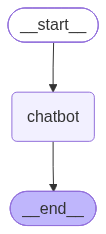

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

In [17]:
config = {"configurable": {"thread_id": "1"}}

result = graph.invoke(
    {"messages": [("user", "Hi, I'm Kartik. Explain LangGraph in one line.")]},
    config,
)
print("Assistant:", result["messages"][-1].text)

result = graph.invoke({"messages": [("user", "What's my name?")]}, config)
print("Assistant:", result["messages"][-1].text)

Assistant: Hi Kartik! LangGraph is a framework for building complex, stateful, and cyclical multi-agent LLM applications using graph-based workflows.
Assistant: Your name is Kartik!


In [18]:
config = {"configurable": {"thread_id": "1"}}  # change the id to start a fresh conversation

while True:
    user_input = input("User: ")
    if user_input.strip().lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    try:
        for event in graph.stream({"messages": [("user", user_input)]}, config):
            for value in event.values():
                print("Assistant:", value["messages"][-1].text)
    except Exception as e:
        print(f"Error: {e}")
        break

User: who is messi?
Assistant: **Lionel Messi** is an Argentine professional footballer widely regarded as one of the greatest players in the history of the sport (often referred to as the "GOAT"). 

Here are the key highlights about him:

* **Nationality & Position:** He plays as a forward and captains both Major League Soccer (MLS) club **Inter Miami** and the **Argentina national team**.
* **FC Barcelona Era:** He spent the majority of his career (2004–2021) at FC Barcelona, where he won 35 trophies, including 10 La Liga titles and 4 UEFA Champions League titles, becoming the club's all-time top scorer.
* **International Success:** He led Argentina to victory in the **2021 Copa América** and fulfilled a lifelong dream by winning the **2022 FIFA World Cup** in Qatar.
* **Individual Honors:** He has won a record **8 Ballon d'Or awards** (given to the world's best player) and 6 European Golden Shoes. 
* **Other Clubs:** Before moving to Inter Miami in 2023, he played two seasons for Fr

In [19]:
for m in graph.get_state(config).values["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi, I'm Kartik. Explain LangGraph in one line.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hi Kartik! LangGraph is a framework for building complex, stateful, and cyclical multi-agent LLM applications using graph-based workflows.', 'extras': {'signature': 'EtcLCtQLAWkUfRO19KapIxhZSGjp+DwHmn63dJIELqCCh7D6PqDrsb+AszcJTV/Gt7eCbOaS0imP8SHQHjyTWi+mOaWNzUiwMkxqJr2MS2lm3jkfASRE6ZTIg24GLKU1cPdpb5fOqtswTjBK3Jnt3A0tv0ZG6nBtkkPBuPr6TfB7KR+M8fr5aVjpWafdB+82SrZ5D3Gzp06ilRUUZOXGpoOziS9Sif31iL8hHMY6TP4ddjSxLAm3npYYpcx4cyNfx++DOvpYefCdd/p42yzQKCTCaHu62S717cIonAjJaabT+Blh2TYVHrDcWioUp4+RD1jS44jpAs+TmyGlzxWDNrTP2TIOOo3tq8nIN8lWzEcTL9cNVHPTUbalqGEaOtSsjT9eboVpYCj1m0V4gLwdtN3/boixtrZYGtcCNrGhzjUmxsfeC/nJ/ipVpBZvnQK3HTZjDxT2wLpMZnxQBsDCNw9ZcjCO/H24aC4vReWz61MBJf2b1L5+3Y8DZqK9x7Iejcxpg6XBrRZKo7u1xb8rspsOneeUaYTUq+8QSa0gw2VKS2RNeVT+GO7S+ogV5iAj29f01/YE4liNa3gx12vW